Title: Gold Price Prediction using GRU

Objective: To predict future gold prices using a GRU (Gated Recurrent Unit) deep learning model.

In [19]:
!pip install yfinance

import yfinance as yf

gold = yf.download("GC=F", start="2018-01-01", end="2025-01-01")

gold.to_csv("gold_price.csv")

gold.head()

/tmp/ipykernel_639/2893101964.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("GC=F", start="2018-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2018-01-02,1313.699951,1317.599976,1302.300049,1302.300049,68
2018-01-03,1316.199951,1320.099976,1312.099976,1320.000000,42
2018-01-04,1319.400024,1322.000000,1319.400024,1319.400024,2
2018-01-05,1320.300049,1320.300049,1320.300049,1320.300049,1
2018-01-08,1318.599976,1319.900024,1314.599976,1319.900024,41


In [3]:
gold.shape

(1760, 5)

In [4]:
gold.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1760 entries, 2018-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GC=F)   1760 non-null   float64
 1   (High, GC=F)    1760 non-null   float64
 2   (Low, GC=F)     1760 non-null   float64
 3   (Open, GC=F)    1760 non-null   float64
 4   (Volume, GC=F)  1760 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 82.5 KB


In [5]:
import pandas as pd

data = gold[['Close']]
data.head()

Price,Close
Ticker,GC=F
Date,
2018-01-02,1313.699951
2018-01-03,1316.199951
2018-01-04,1319.400024
2018-01-05,1320.300049
2018-01-08,1318.599976


In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [7]:
import numpy as np

X = []
y = []

time_step = 60

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(1700, 60)
(1700,)


In [8]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)

(1700, 60, 1)


In [9]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

model = Sequential()

model.add(
    GRU(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)

model.add(GRU(units=64))

model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,889 (148.00 KB)

 Trainable params: 37,889 (148.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0088 - val_loss: 0.0039
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 2.8972e-04 - val_loss: 4.1886e-04
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 2.2729e-04 - val_loss: 6.1511e-04
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 2.1274e-04 - val_loss: 3.3891e-04
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 2.0446e-04 - val_loss: 4.4897e-04
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 1.8958e-04 - val_loss: 3.8105e-04
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 1.9595e-04 - val_loss: 3.0146e-04
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 1.7982e-04 - val_loss: 4.6985e-04
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 1.7809e-04 - val_loss: 6.7450e-04
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 1.8385e-04 - val_loss: 2.7016e-04
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 1.6139e-04 - val_

In [12]:
predictions = model.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step


In [13]:
predictions = scaler.inverse_transform(
    predictions.reshape(-1,1)
)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(actual,predictions))
mae = mean_absolute_error(actual,predictions)

print("RMSE:", rmse)
print("MAE :", mae)

RMSE: 42.69666697323163
MAE : 35.811957864200366


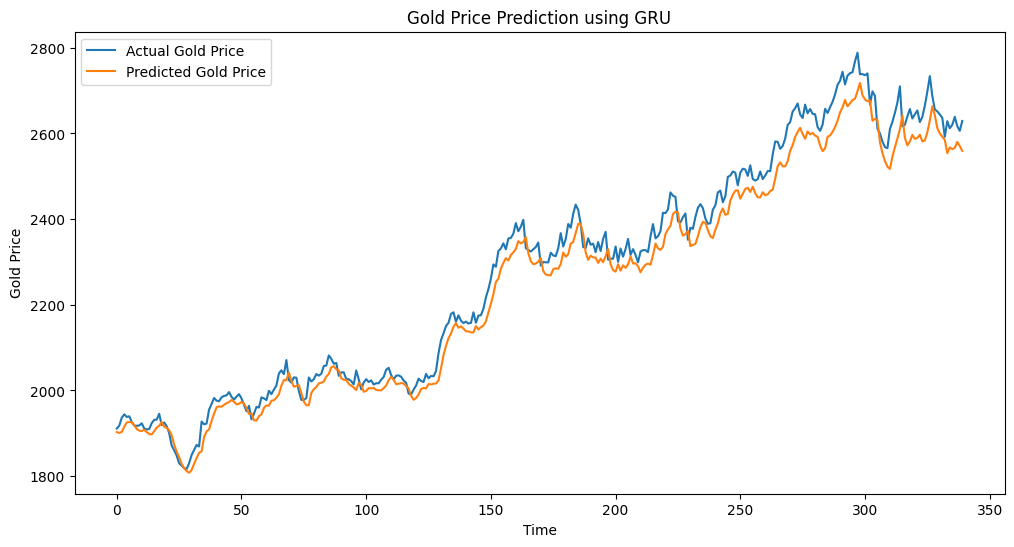

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(actual,label='Actual Gold Price')
plt.plot(predictions,label='Predicted Gold Price')

plt.title('Gold Price Prediction using GRU')
plt.xlabel('Time')
plt.ylabel('Gold Price')
plt.legend()

plt.show()

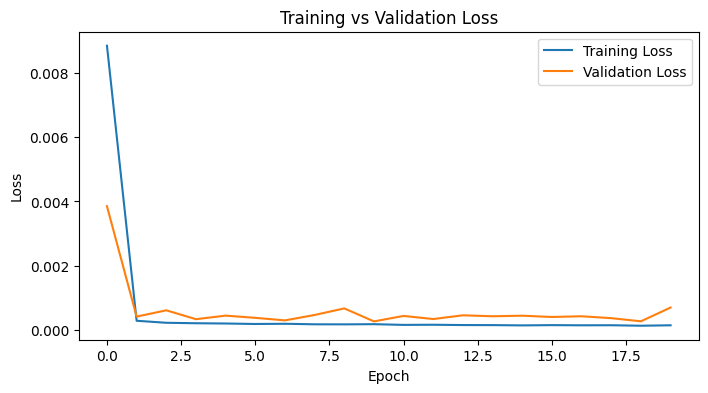

In [18]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Conclusion: The GRU model successfully learned historical gold price patterns and generated predictions close to actual prices. The prediction curve followed the real trend, showing that GRU is effective for time-series forecasting.